In [2]:
###just copy all libraries from WorkShop..
# Core Libraries
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and Model Selection
from scikeras.wrappers import KerasClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

# Evaluation Metrics
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

In [3]:
# Upload the data
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)
#Note: if we don't include header=none, i noticed that the first row o data is treated as the header and we lose data.

#Now make sure they're imported correctly and check the sahpes:
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)



Training set shape: (87554, 188)
Testing set shape: (21892, 188)


In [4]:
#Check first few rows of data; to see what it looks like, to see the balance:
print(train_df.head())

#check last column is it 4 or 5 ? 
print(train_df.iloc[:, -1].unique())

#check how many samples there are per class?
print(train_df.iloc[:,-1].value_counts().sort_index())

        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0 

In [5]:
"""
Very important things we can notice from the dataset:
-- our data is 1D numerical time-series ECG heartbeat signal data --
1- all values are between 0 - 1.
2- last column is 4 , lables are from 0 to 4 so no need for label encoding.
3- very very big imbalance in train classes!!?
Class 3 (Type2) only 641 sample comparing to 72,471 in class 0 !
That could cause in making the model lazy so we must create more samples for type 3 to train the model on.
***Keep in mind for the report***
"""


'\nVery important things we can notice from the dataset:\n-- our data is 1D numerical time-series ECG heartbeat signal data --\n1- all values are between 0 - 1.\n2- last column is 4 , lables are from 0 to 4 so no need for label encoding.\n3- very very big imbalance in train classes!!?\nClass 3 (Type2) only 641 sample comparing to 72,471 in class 0 !\nThat could cause in making the model lazy so we must create more samples for type 3 to train the model on.\n***Keep in mind for the report***\n'

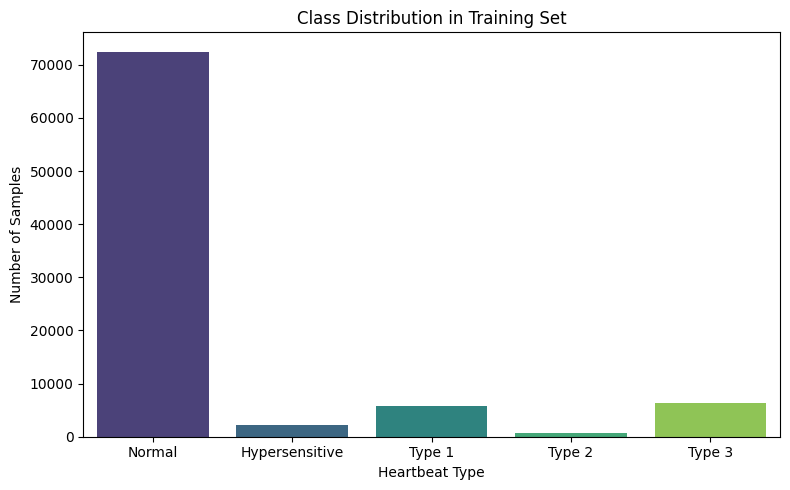


Percentage per class:
Class 0 (Normal): 72471 samples — 82.8%
Class 1 (Hypersensitive): 2223 samples — 2.5%
Class 2 (Type 1): 5788 samples — 6.6%
Class 3 (Type 2): 641 samples — 0.7%
Class 4 (Type 3): 6431 samples — 7.3%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualise the dataset, (More understanding) and look at the imbalance
class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Heartbeat Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()
#### TO INCLUDE IN REPORT###
print("\nPercentage per class:")
for i, (count, name) in enumerate(zip(class_counts.values, class_names)):
    print(f"Class {i} ({name}): {count} samples — {count/len(train_df)*100:.1f}%")

In [7]:
#it's obvious how bas the samples is so that is something to keep in mind
#Now must check the missing values in teaining and test values (datasets clean or not?)
print("Missing in training:")
print(train_df.isnull().sum().sum())
print("\nMissing in test:")
print(test_df.isnull().sum().sum())

# Result is 0, good. > Clean Data.


Missing in training:
0

Missing in test:
0


In [8]:
#Before doing one hot encoding, i want to split the dta i want to split the data into x and y to do hot encoding to lables only.
X_train = train_df.iloc[:, :-1].values #all col. except thd last.
y_train = train_df.iloc[:, -1].values #last col. only.

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("First sample label:", y_train[0]) #Just to make sure.




X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)
First sample label: 0.0


In [9]:
#Now One-Hot Encoding:
from tensorflow.keras.utils import to_categorical
#Converting lables to int. first, then encode.
y_train_encoded = to_categorical(y_train.astype(int), num_classes=5)
y_test_encoded = to_categorical(y_test.astype(int), num_classes=5)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

#Now one hot encoding is done, start building CNN network.

y_train_encoded shape: (87554, 5)
y_test_encoded shape: (21892, 5)


In [19]:
#Normalisation of data:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test only

print("X_train_scaled shape:", X_train_scaled.shape)  # (87554, 187)
print("X_test_scaled shape:", X_test_scaled.shape)    # (21892, 187)

X_train_scaled shape: (87554, 187)
X_test_scaled shape: (21892, 187)


In [ ]:
"""
Reshape the data: 
will be adding the channels as CNN requires
"""
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("X_train reshaped:", X_train_cnn.shape)
print("X_test reshaped:", X_test_cnn.shape)
#Now ready for CNN.

X_train reshaped: (87554, 187, 1)
X_test reshaped: (21892, 187, 1)


In [21]:
#Class Weights: 
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train.astype(int))
weights = compute_class_weight('balanced', classes=classes, y=y_train.astype(int))
class_weight_dict = dict(zip(classes, weights))

print("Class weights:")
for cls, w in class_weight_dict.items():
    print(f"  Class {cls} ({class_names[cls]}): {w:.4f}")

Class weights:
  Class 0 (Normal): 0.2416
  Class 1 (Hypersensitive): 7.8771
  Class 2 (Type 1): 3.0254
  Class 3 (Type 2): 27.3179
  Class 4 (Type 3): 2.7229


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense

model = Sequential([
    # First Block
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Second Block
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Third Block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Fully Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output Layer
    Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       327,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,485 (1.42 MB)

 Trainable params: 372,037 (1.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
"""
-----FOR REPORT----
Data enters as (187, 1) — one heartbeat signal
Three convolutional blocks progressively extract patterns: 32 → 64 → 128 filters
After flattening you get 2560 values summarising the whole signal
Two dense layers make sense of those values
Final layer outputs 5 probabilities — one per heartbeat class
Total of 372,485 parameters to learn — a solid sized model
"""

'\n-----FOR REPORT----\nData enters as (187, 1) — one heartbeat signal\nThree convolutional blocks progressively extract patterns: 32 → 64 → 128 filters\nAfter flattening you get 2560 values summarising the whole signal\nTwo dense layers make sense of those values\nFinal layer outputs 5 probabilities — one per heartbeat class\nTotal of 372,485 parameters to learn — a solid sized model\n'

In [13]:
#Compile the model:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [14]:
"""
why??
Adam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method
Categorical Cross-Entropy — the standard loss function for multiclass classification. This is the classification equivalent of the least squares loss your lecturer showed
Accuracy — simple metric to monitor during training

"""

'\nwhy??\nAdam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method\nCategorical Cross-Entropy — the standard loss function for multiclass classification. This is the classification equivalent of the least squares loss your lecturer showed\nAccuracy — simple metric to monitor during training\n\n'

In [15]:
#Training the network;
""" call early stopping and ModelCheck point before training to 
1- stop training the model if there's no improving
2- avoid overfitting
3- save best version of the model automatically
"""

" call early stopping and ModelCheck point before training to \n1- stop training the model if there's no improving\n2- avoid overfitting\n3- save best version of the model automatically\n"

In [16]:
#Now train :

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#Stop if loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save best model automatically
model_checkpoint = ModelCheckpoint(
    'ANN-model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_cnn, y_train_encoded,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\nTraining complete!")
#Commented it out for now because it's an over-fit model.

Epoch 1/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9899 - loss: 0.0385
Epoch 1: val_loss improved from None to 13.43914, saving model to ANN-model.keras

Epoch 1: finished saving model to ANN-model.keras
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 67s 56ms/step - accuracy: 0.9986 - loss: 0.0055 - val_accuracy: 0.1387 - val_loss: 13.4391
Epoch 2/30
1094/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 5.7755e-05
Epoch 2: val_loss did not improve from 13.43914
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - accuracy: 1.0000 - loss: 4.8765e-05 - val_accuracy: 0.1387 - val_loss: 32.6277
Epoch 3/30
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 3.4425e-07
Epoch 3: val_loss did not improve from 13.43914
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 52s 47ms/step - accuracy: 1.0000 - loss: 5.0547e-07 - val_accuracy: 0.1387 - val_loss: 31.6184
Epoch 4/30
1094/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 6.7909e-07
Epoch 4: val_loss did not imp

In [ ]:
"""
---REPORT----
Training will go through up to 30 epochs
Each epoch processes all 87,554 training samples
You'll see loss and accuracy printed each epoch
It will stop early if it stops improving
"""
"""
After training the first time i can notice 100% accuracy in training , 13,87 Validation
loss is close to 0 in training and validation 42.26
this is extreme overfitting , model just memorised the training data but learned nothing useful
validation of 13.87 is worse than random guessing.
The proplem? Class Imbalance: Normal heartbeats:82.8%
                                Type 2 heartbeats: 0.7%
model just learned to predict "NORMAL" for almost everything
THE FIX? >> CLASS WEIGHTS 
CHECKING FOR CLASS WEIGHTS>> """
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.astype(int)),
    y=y_train.astype(int)
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
for i, (weight, name) in enumerate(zip(class_weights, class_names)):
    print(f"  Class {i} ({name}): {weight:.4f}")
""" class weights are significantly higher for the minority classes, especially Type 2 which is the most underrepresented. This will force the model to pay more attention to those classes during training.
i've already done that step before .. (incluing that).
How to fix? > shuffle the data, simpler model with less layers , lower learning rate to learn more carefully , smaller batch size """


Class weights:
  Class 0 (Normal): 0.2416
  Class 1 (Hypersensitive): 7.8771
  Class 2 (Type 1): 3.0254
  Class 3 (Type 2): 27.3179
  Class 4 (Type 3): 2.7229


' class weights are significantly higher for the minority classes, especially Type 2 which is the most underrepresented. This will force the model to pay more attention to those classes during training.\nHow to fix? > shuffle the data, simpler model with less layers , lower learning rate to learn more carefully , smaller batch size '

In [18]:
from sklearn.utils import shuffle

#Shuffle everything together
X_train_s, y_train_s = shuffle(X_train_cnn, y_train_encoded, random_state=42)

#Simpler model:
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', 
           input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(5, activation='softmax')
])

#Lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Retrain on shuffled data
history = model.fit(
    X_train_s, y_train_s,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/30
2188/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4367 - loss: 1.3211
Epoch 1: val_loss improved from 13.43914 to 1.16551, saving model to ANN-model.keras

Epoch 1: finished saving model to ANN-model.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.5186 - loss: 1.0266 - val_accuracy: 0.5121 - val_loss: 1.1655
Epoch 2/30
2187/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6277 - loss: 0.7230
Epoch 2: val_loss improved from 1.16551 to 0.90196, saving model to ANN-model.keras

Epoch 2: finished saving model to ANN-model.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.6441 - loss: 0.7075 - val_accuracy: 0.6832 - val_loss: 0.9020
Epoch 3/30
1997/2189 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7053 - loss: 0.5865

KeyboardInterrupt: 